<a href="https://colab.research.google.com/github/sankalp120/machinelearning/blob/main/mllab12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Data

First, we need to load the `Mall_Customers.csv` dataset. Please ensure you have downloaded it from the Kaggle link provided and uploaded it to your Colab environment.

In [7]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
X = df_clustering[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Apply StandardScaler to the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('First 5 rows of scaled features:')
display(pd.DataFrame(X_scaled, columns=X.columns).head())

First 5 rows of scaled features:


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


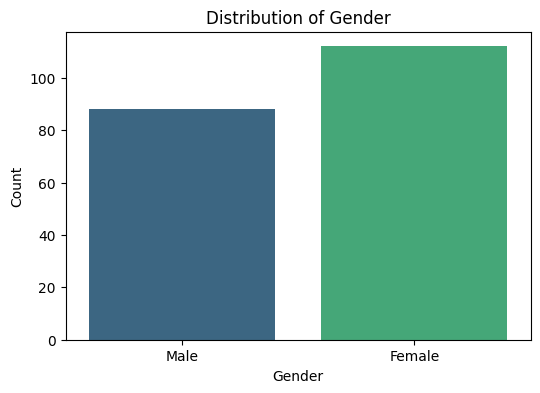

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df, hue='Gender', palette='viridis', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [5]:
import pandas as pd

try:
    df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')
    print('Dataset loaded successfully.')
    print('\nFirst 5 rows of the dataset:')
    display(df.head())
    print('\nDataset Information:')
    df.info()
except FileNotFoundError:
    print("Error: 'Mall_Customers.csv' not found. Please upload the file to your Colab environment.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully.

First 5 rows of the dataset:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### Data Preprocessing and Exploratory Data Analysis (EDA)

First, let's check for any missing values in the dataset.

In [11]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Next, let's look at the distribution of the numerical features: `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. Histograms are a good way to visualize these distributions.

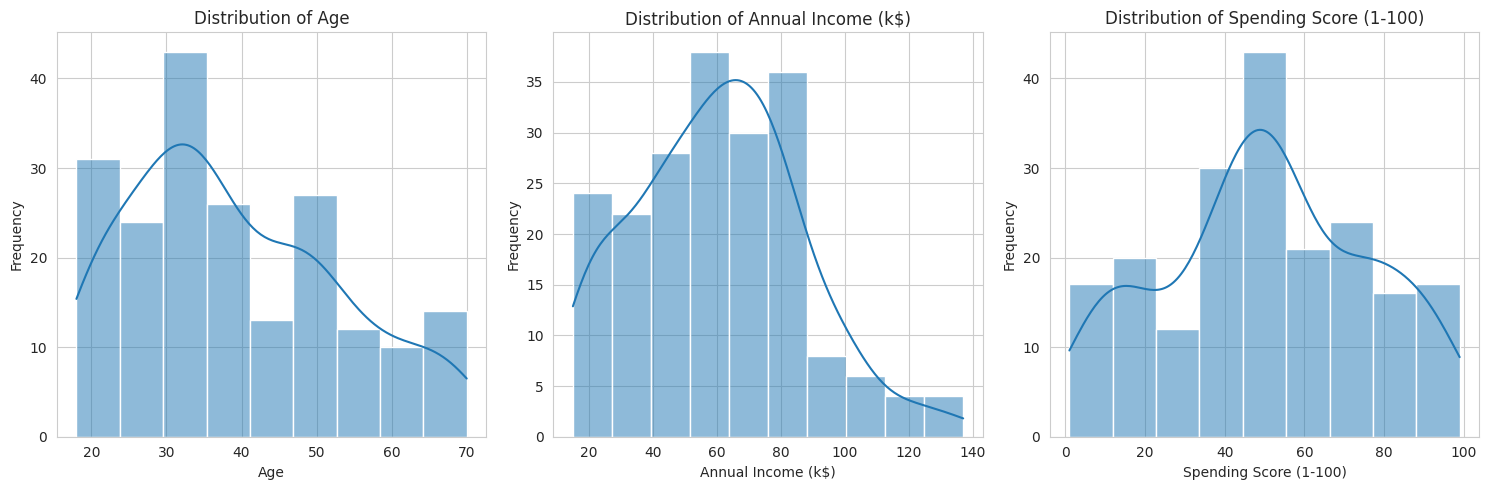

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style('whitegrid')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df['Annual Income (k$)'], kde=True)
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.title('Distribution of Spending Score (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Let's also examine the distribution of the categorical feature: `Gender`.

### Data Preparation for Clustering

To prepare our data for K-Means clustering, we need to perform two main steps:
1. **Encode Categorical Features**: Convert categorical variables (like 'Gender') into numerical representations.
2. **Feature Scaling**: Scale numerical features to ensure that each feature contributes equally to the distance calculations in K-Means, as it is sensitive to the magnitude of features.

First, let's encode the 'Gender' column using one-hot encoding.

In [13]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataframe for clustering
df_clustering = df.copy()

# Encode Gender column
le = LabelEncoder()
df_clustering['Gender'] = le.fit_transform(df_clustering['Gender'])

print('DataFrame after Gender encoding:')
display(df_clustering.head())

DataFrame after Gender encoding:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


Next, we will select the features relevant for clustering and apply feature scaling using `StandardScaler`.

### Determine Optimal Number of Clusters (K) using Elbow Method

To find the optimal number of clusters `k` for K-Means, we will use the Elbow Method. This method involves plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters and looking for the 'elbow' point where the rate of decrease in WCSS significantly changes.

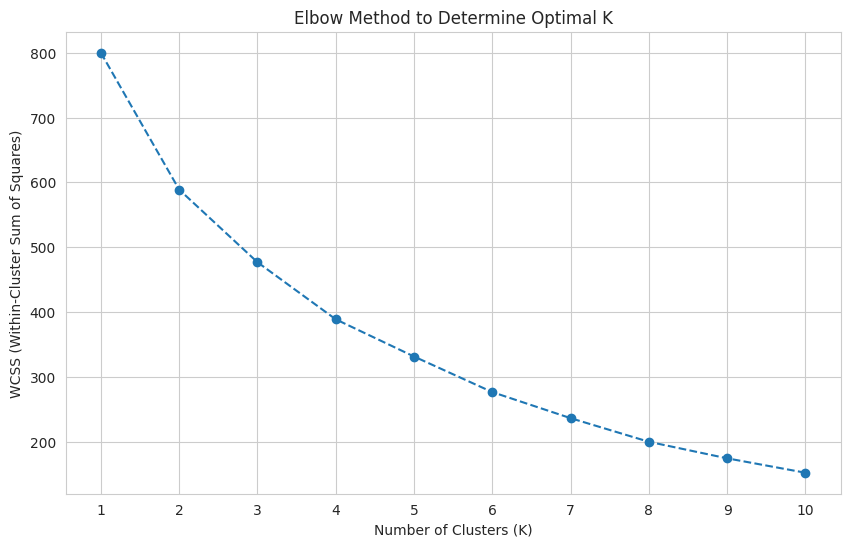

In [14]:
from sklearn.cluster import KMeans

wcss = []
# Try a range of k values from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10) # n_init is set to 10 to suppress warning
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

### Determine Optimal Number of Clusters (K) using Elbow Method

To find the optimal number of clusters `k` for K-Means, we will use the Elbow Method. This method involves plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters and looking for the 'elbow' point where the rate of decrease in WCSS significantly changes.

### K-Means Clustering and Visualization

Based on the Elbow Method, we will proceed with **5 clusters**. We will now apply the K-Means algorithm to segment the customers and then visualize these clusters.

In [15]:
from sklearn.cluster import KMeans

# Apply K-Means with the optimal number of clusters (K=5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original dataframe
df_clustering['Cluster'] = y_kmeans

print('First 5 rows of the dataframe with cluster labels:')
display(df_clustering.head())

First 5 rows of the dataframe with cluster labels:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,3
2,3,0,20,16,6,3
3,4,0,23,16,77,3
4,5,0,31,17,40,3


Now, let's visualize the clusters, focusing on 'Annual Income (k$)' and 'Spending Score (1-100)', as these are often strong discriminators for customer segments. We will use the original unscaled values for better interpretability.

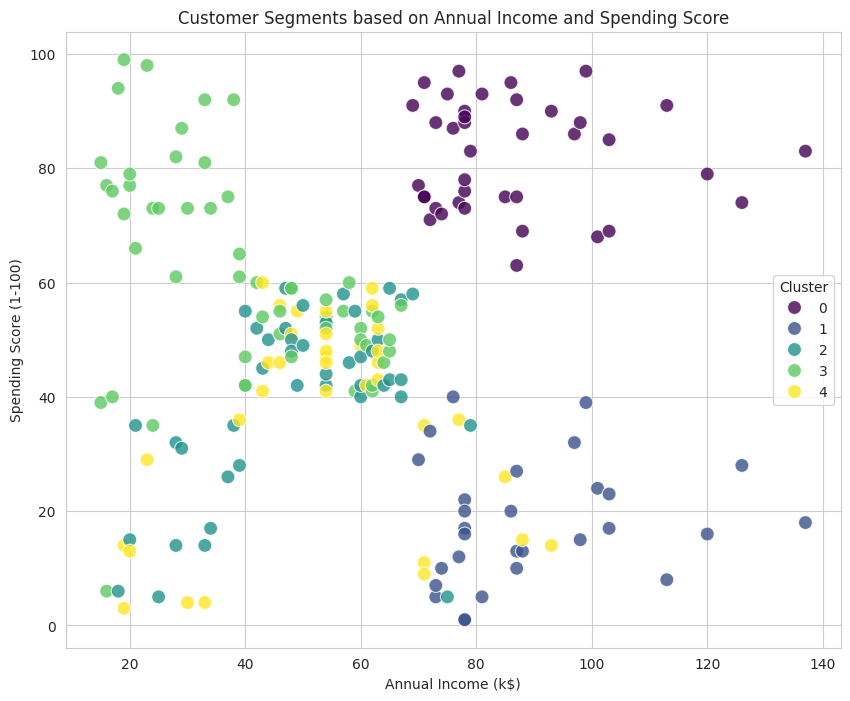

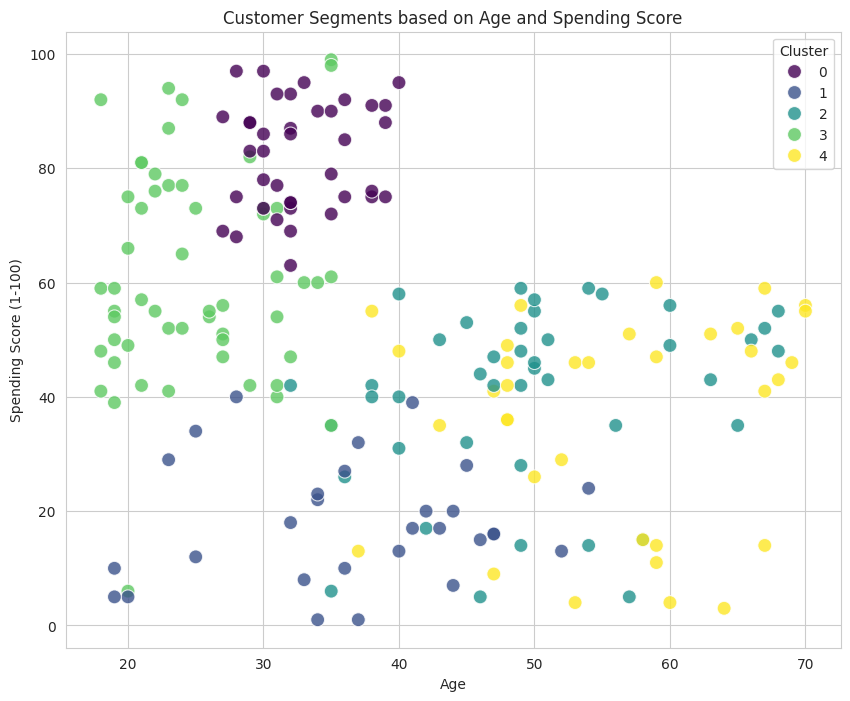

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

# You can also visualize with Age
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Age', y='Spending Score (1-100)', hue='Cluster', data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('Customer Segments based on Age and Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

### Cluster Analysis

To understand the characteristics of each customer segment, we will analyze the mean values of the features within each cluster.

Mean values of features per cluster:


,Age,Annual Income (k$),Spending Score (1-100),Gender
Cluster,,,,
0,32.692308,86.538462,82.128205,Female
1,36.482759,89.517241,18.000000,Female
2,49.813953,49.232558,40.069767,Female
3,24.907407,39.722222,61.203704,Female
4,55.714286,53.685714,36.771429,Male


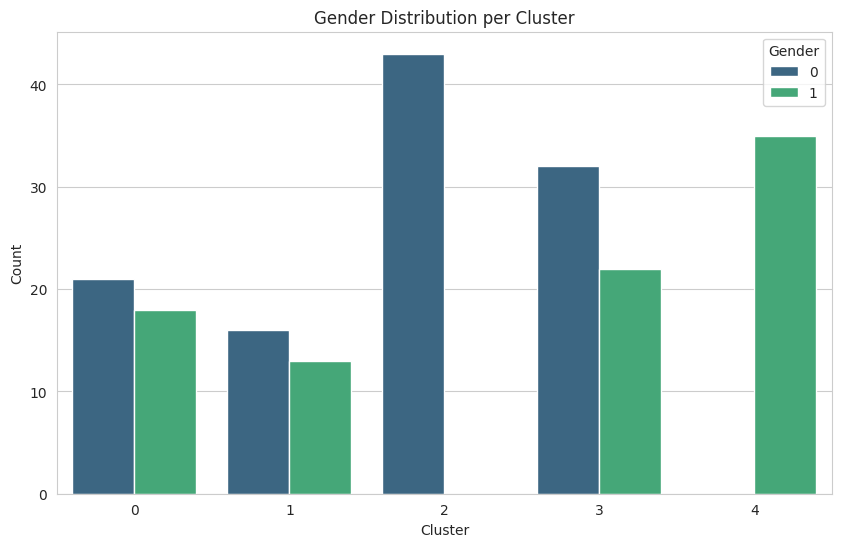

In [18]:
cluster_means = df_clustering.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].mean()

# Convert Gender back to original labels for better interpretability if needed for display
# 0: Female, 1: Male
cluster_means['Gender'] = cluster_means['Gender'].apply(lambda x: 'Male' if x > 0.5 else 'Female' if x < 0.5 else 'Mixed')

print('Mean values of features per cluster:')
display(cluster_means)

# Visualize gender distribution per cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', hue='Gender', data=df_clustering, palette='viridis')
plt.title('Gender Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

This analysis helps us describe each customer segment based on their average age, annual income, spending score, and gender distribution. Based on these insights, we can give meaningful names to each cluster, such as 'High Income, High Spend', 'Average Income, Average Spend', etc.

from sklearn.mixture import GaussianMixture
import seaborn as sns
import matplotlib.pyplot as plt

# Apply GMM with 5 components (clusters)
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Predict the cluster labels
y_gmm = gmm.predict(X_scaled)

# Add the GMM cluster labels to the dataframe
df_clustering['GMM_Cluster'] = y_gmm

print('First 5 rows of the dataframe with GMM cluster labels:')
display(df_clustering.head())

# Visualize the GMM clusters based on Annual Income and Spending Score
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='GMM_Cluster',
                data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('GMM Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='GMM Cluster')
plt.show()

First 5 rows of the dataframe with DBSCAN cluster labels:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN_Cluster
0,1,1,19,15,39,3,-1
1,2,1,21,15,81,3,-1
2,3,0,20,16,6,3,-1
3,4,0,23,16,77,3,0
4,5,0,31,17,40,3,-1


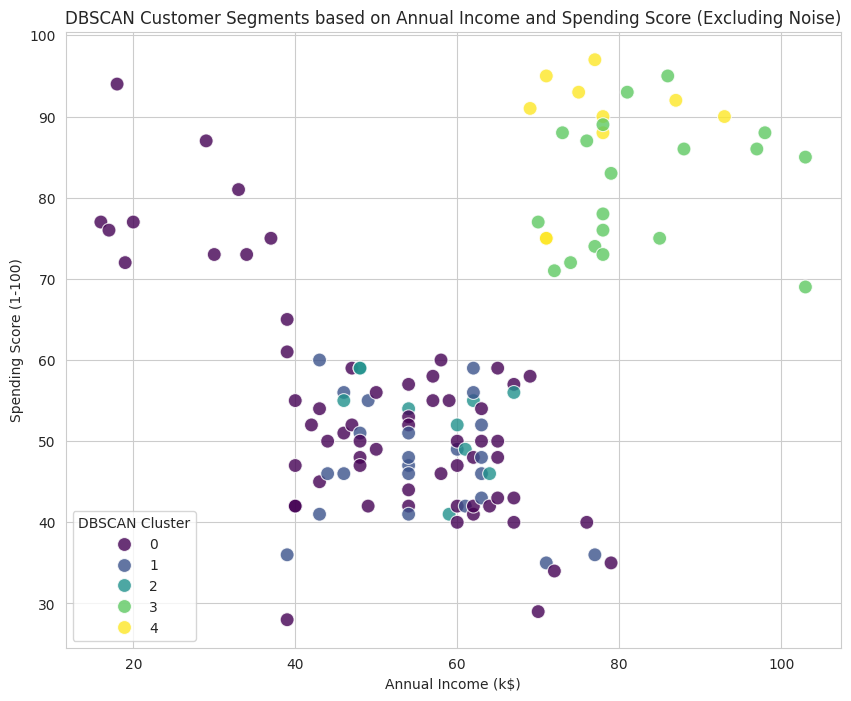

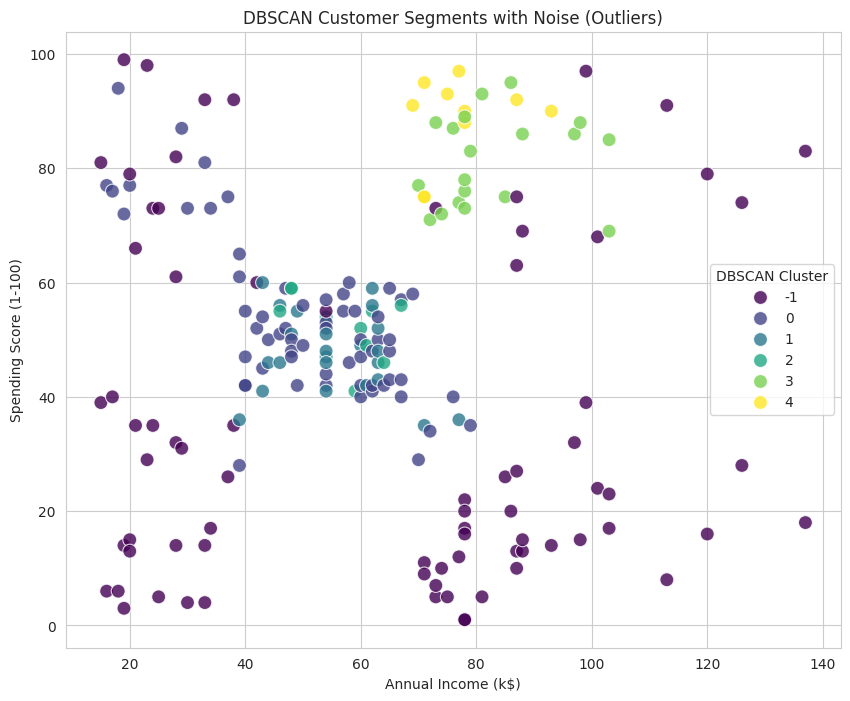


Number of points in each DBSCAN cluster:
DBSCAN_Cluster
-1    76
 0    62
 1    23
 3    19
 2    10
 4    10
Name: count, dtype: int64


In [20]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

# Apply DBSCAN with initial parameters
dbsc = DBSCAN(eps=0.7, min_samples=8) # Using initial parameters discussed
dbsc.fit(X_scaled)

# Add the DBSCAN cluster labels to the dataframe
df_clustering['DBSCAN_Cluster'] = dbsc.labels_

print('First 5 rows of the dataframe with DBSCAN cluster labels:')
display(df_clustering.head())

# Visualize the DBSCAN clusters (excluding noise points for clearer visualization of clusters)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster',
                data=df_clustering[df_clustering['DBSCAN_Cluster'] != -1],
                palette='viridis', s=100, alpha=0.8)
plt.title('DBSCAN Customer Segments based on Annual Income and Spending Score (Excluding Noise)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='DBSCAN Cluster')
plt.show()

# Visualize with noise points included to see outliers
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster',
                data=df_clustering,
                palette='viridis', s=100, alpha=0.8)
plt.title('DBSCAN Customer Segments with Noise (Outliers)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='DBSCAN Cluster')
plt.show()

# Count the number of points in each cluster, including noise (-1)
print('\nNumber of points in each DBSCAN cluster:')
print(df_clustering['DBSCAN_Cluster'].value_counts())

### Hierarchical Clustering and Dendrogram

Now, let's apply hierarchical clustering to the scaled data (`X_scaled`) and visualize the cluster formation using a dendrogram. A dendrogram helps in determining the optimal number of clusters by observing the largest vertical distance that can be cut without crossing any horizontal lines.

We'll use `scipy.cluster.hierarchy` for generating the dendrogram and `sklearn.cluster.AgglomerativeClustering` for the actual clustering once we decide on the number of clusters.

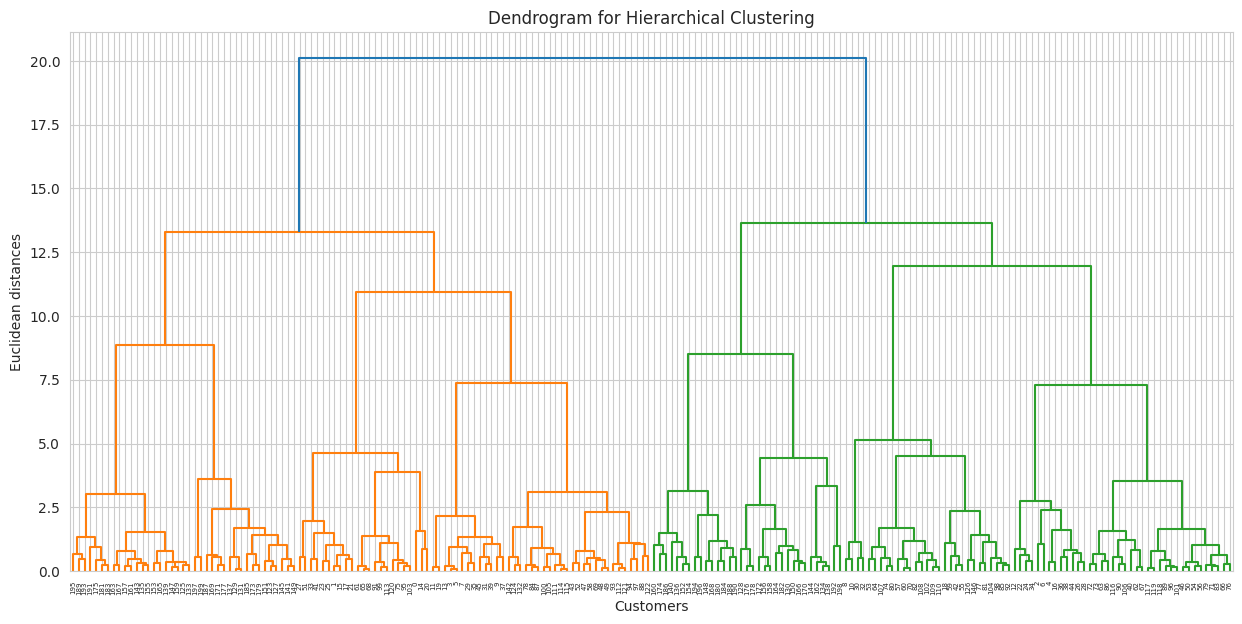

In [21]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.title('Dendrogram for Hierarchical Clustering')

# Create the dendrogram
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))

plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.grid(True)
plt.show()

From the dendrogram, we can observe the merging of clusters. To determine the optimal number of clusters, we look for the longest vertical line that does not intersect any extended horizontal line. This usually suggests a good cut-off point.

Let's assume, for instance, that we decide on **5 clusters** based on the dendrogram (similar to what K-Means suggested earlier). We can then apply `AgglomerativeClustering` with this number of clusters and add the cluster labels to our dataframe.

### Hierarchical Cluster Analysis

To understand the characteristics of each customer segment identified by hierarchical clustering, we will analyze the mean values of the features within each cluster.

Mean values of features per hierarchical cluster:


,Age,Annual Income (k$),Spending Score (1-100),Gender
Hierarchical_Cluster,,,,
0,26.147541,43.770492,58.967213,Female
1,32.692308,86.538462,82.128205,Female
2,41.454545,89.090909,16.181818,Male
3,49.789474,44.105263,39.657895,Female
4,56.551724,50.034483,41.344828,Male


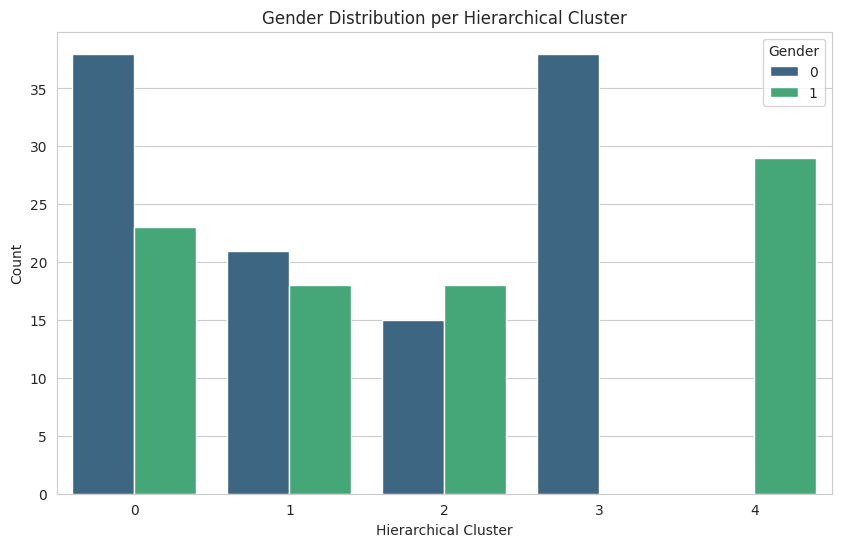

In [23]:
hierarchical_cluster_means = df_clustering.groupby('Hierarchical_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].mean()

# Convert Gender back to original labels for better interpretability if needed for display
# 0: Female, 1: Male
hierarchical_cluster_means['Gender'] = hierarchical_cluster_means['Gender'].apply(lambda x: 'Male' if x > 0.5 else 'Female' if x < 0.5 else 'Mixed')

print('Mean values of features per hierarchical cluster:')
display(hierarchical_cluster_means)

# Visualize gender distribution per hierarchical cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Hierarchical_Cluster', hue='Gender', data=df_clustering, palette='viridis')
plt.title('Gender Distribution per Hierarchical Cluster')
plt.xlabel('Hierarchical Cluster')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

First 5 rows of the dataframe with Hierarchical cluster labels:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN_Cluster,Hierarchical_Cluster
0,1,1,19,15,39,3,-1,0
1,2,1,21,15,81,3,-1,0
2,3,0,20,16,6,3,-1,3
3,4,0,23,16,77,3,0,0
4,5,0,31,17,40,3,-1,3


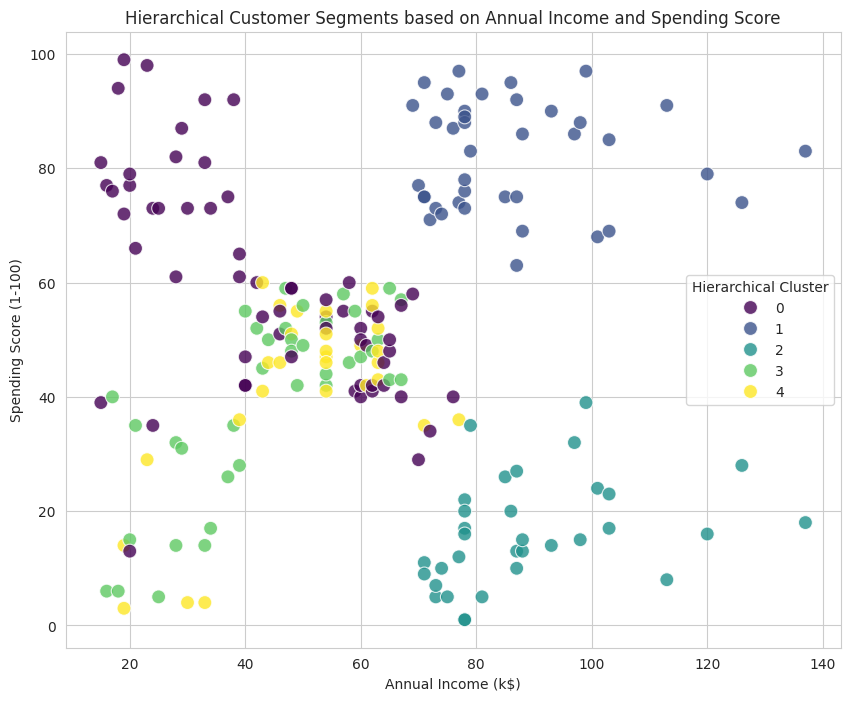

In [22]:
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns

# Apply Agglomerative Hierarchical Clustering with, for example, 5 clusters
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Add the hierarchical cluster labels to the dataframe
df_clustering['Hierarchical_Cluster'] = y_hc

print('First 5 rows of the dataframe with Hierarchical cluster labels:')
display(df_clustering.head())

# Visualize the Hierarchical clusters based on Annual Income and Spending Score
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Hierarchical_Cluster',
                data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('Hierarchical Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='Hierarchical Cluster')
plt.show()

This analysis provides a detailed profile for each hierarchical customer segment. By comparing these profiles, we can give meaningful names to each cluster, such as 'High Income, Low Spend' or 'Young Adults, High Spend', and discuss the differences and similarities between the clustering methods.

### Birch Clustering

Birch clustering is a hierarchical clustering algorithm that first summarizes the data into a CF (Clustering Feature) tree and then applies a global clustering method (like Agglomerative or K-Means) to the leaves of the tree. It is particularly effective for large datasets due to its incremental nature. We will apply Birch clustering with 5 clusters to maintain consistency with our previous analyses.

First 5 rows of the dataframe with Birch cluster labels:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN_Cluster,Hierarchical_Cluster,GMM_Cluster,MeanShift_Cluster,Birch_Cluster
0,1,1,19,15,39,3,-1,0,2,0,4
1,2,1,21,15,81,3,-1,0,2,0,4
2,3,0,20,16,6,3,-1,3,4,0,1
3,4,0,23,16,77,3,0,0,4,0,1
4,5,0,31,17,40,3,-1,3,4,0,1


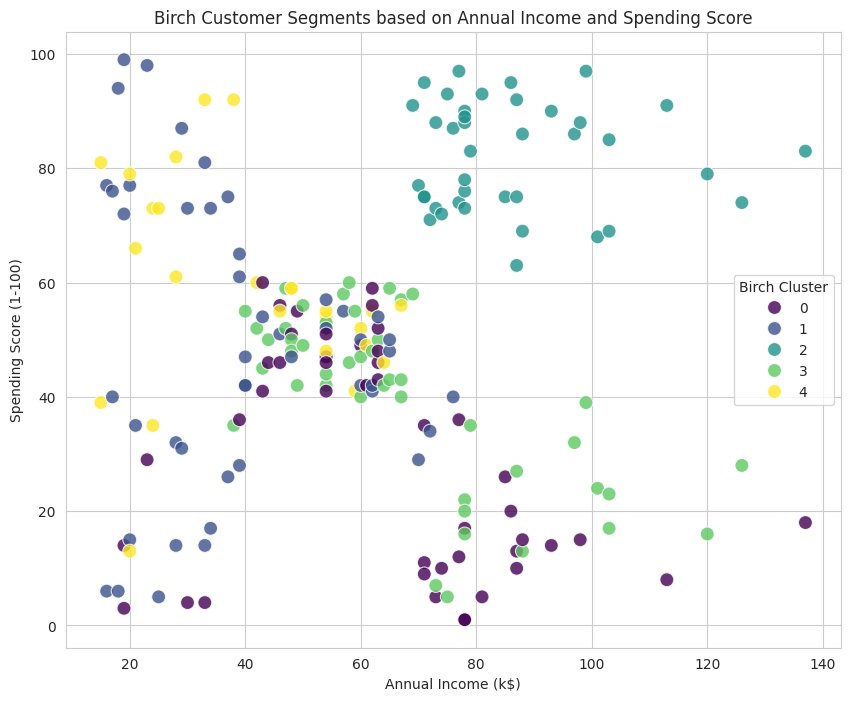

In [37]:
from sklearn.cluster import Birch
import matplotlib.pyplot as plt
import seaborn as sns

# Apply Birch Clustering with 5 clusters
bc = Birch(n_clusters=5)
bc.fit(X_scaled)
y_birch = bc.labels_

# Add the Birch cluster labels to the dataframe
df_clustering['Birch_Cluster'] = y_birch

print('First 5 rows of the dataframe with Birch cluster labels:')
display(df_clustering.head())

# Visualize the Birch clusters based on Annual Income and Spending Score
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Birch_Cluster',
                data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('Birch Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='Birch Cluster')
plt.show()

### Birch Cluster Analysis

To understand the characteristics of each customer segment identified by Birch clustering, we will analyze the mean values of the features within each cluster.

Mean values of features per Birch cluster:


,Age,Annual Income (k$),Spending Score (1-100),Gender
Birch_Cluster,,,,
0,50.244444,64.400000,29.022222,Male
1,30.000000,39.021739,49.000000,Female
2,32.692308,86.538462,82.128205,Female
3,49.133333,67.422222,40.044444,Female
4,25.720000,40.400000,59.000000,Male


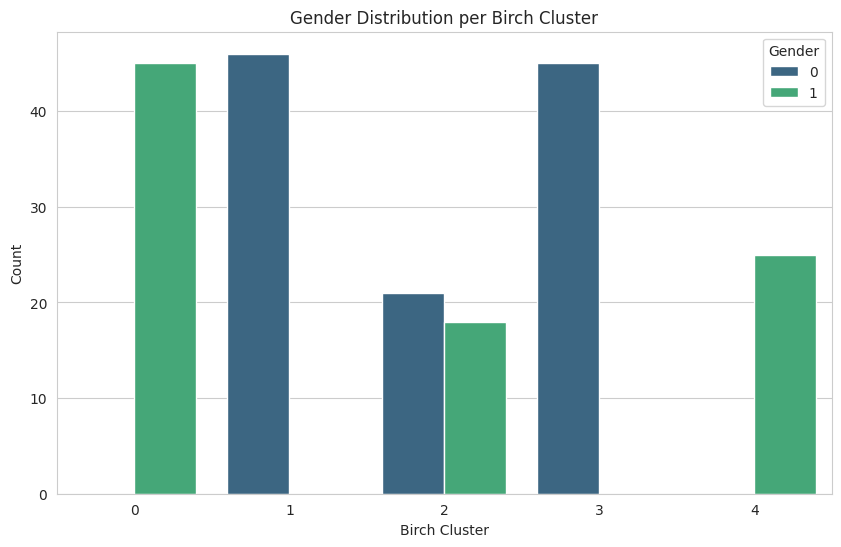

In [38]:
birch_cluster_means = df_clustering.groupby('Birch_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].mean()

# Convert Gender back to original labels for better interpretability if needed for display
# 0: Female, 1: Male
birch_cluster_means['Gender'] = birch_cluster_means['Gender'].apply(lambda x: 'Male' if x > 0.5 else 'Female' if x < 0.5 else 'Mixed')

print('Mean values of features per Birch cluster:')
display(birch_cluster_means)

# Visualize gender distribution per Birch cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Birch_Cluster', hue='Gender', data=df_clustering, palette='viridis')
plt.title('Gender Distribution per Birch Cluster')
plt.xlabel('Birch Cluster')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

GMM

First 5 rows of the dataframe with GMM cluster labels:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,DBSCAN_Cluster,Hierarchical_Cluster,GMM_Cluster,MeanShift_Cluster,Birch_Cluster
0,1,1,19,15,39,3,-1,0,2,0,4
1,2,1,21,15,81,3,-1,0,2,0,4
2,3,0,20,16,6,3,-1,3,4,0,1
3,4,0,23,16,77,3,0,0,4,0,1
4,5,0,31,17,40,3,-1,3,4,0,1


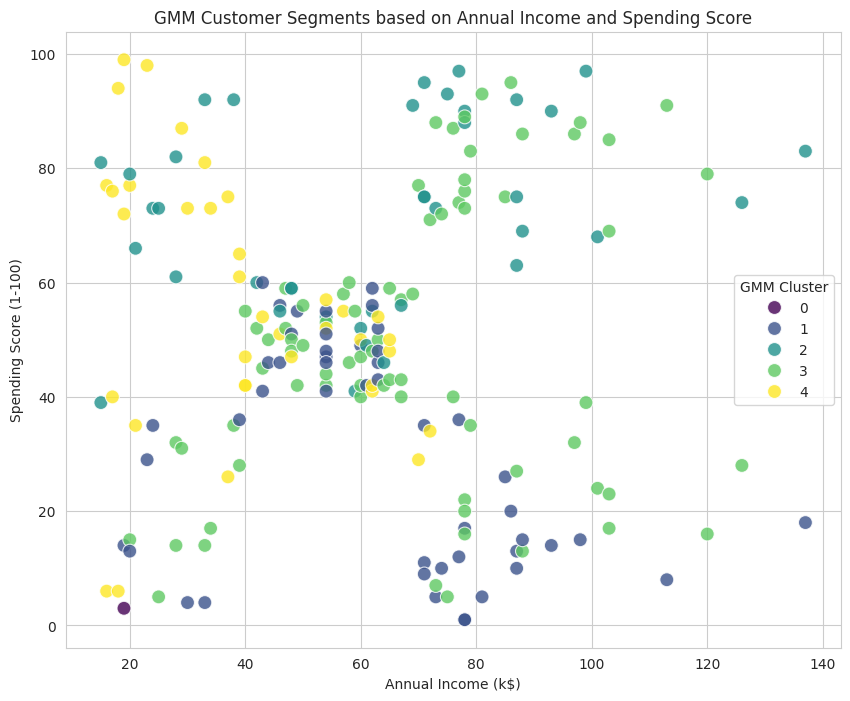

In [36]:
from sklearn.mixture import GaussianMixture
import seaborn as sns
import matplotlib.pyplot as plt

# Apply GMM with 5 components (clusters)
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

# Predict the cluster labels
y_gmm = gmm.predict(X_scaled)

# Add the GMM cluster labels to the dataframe
df_clustering['GMM_Cluster'] = y_gmm

print('First 5 rows of the dataframe with GMM cluster labels:')
display(df_clustering.head())

# Visualize the GMM clusters based on Annual Income and Spending Score
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='GMM_Cluster',
                data=df_clustering, palette='viridis', s=100, alpha=0.8)
plt.title('GMM Customer Segments based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(title='GMM Cluster')
plt.show()

### Gaussian Mixture Model Cluster Analysis

To understand the characteristics of each customer segment identified by Gaussian Mixture Models, we will analyze the mean values of the features within each cluster.

Mean values of features per GMM cluster:


,Age,Annual Income (k$),Spending Score (1-100),Gender
GMM_Cluster,,,,
0,64.000000,19.000000,3.000000,Male
1,48.895833,63.145833,30.291667,Male
2,28.000000,62.205128,72.102564,Male
3,43.815789,68.592105,49.407895,Female
4,26.027778,39.527778,56.000000,Female


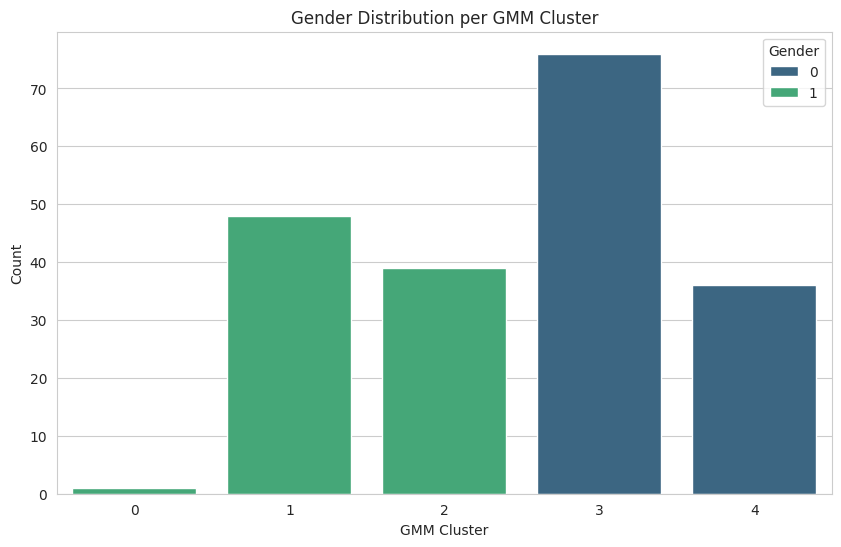

In [41]:
gmm_cluster_means = df_clustering.groupby('GMM_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].mean()

# Convert Gender back to original labels for better interpretability if needed for display
# 0: Female, 1: Male
gmm_cluster_means['Gender'] = gmm_cluster_means['Gender'].apply(lambda x: 'Male' if x > 0.5 else 'Female' if x < 0.5 else 'Mixed')

print('Mean values of features per GMM cluster:')
display(gmm_cluster_means)

# Visualize gender distribution per GMM cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='GMM_Cluster', hue='Gender', data=df_clustering, palette='viridis')
plt.title('Gender Distribution per GMM Cluster')
plt.xlabel('GMM Cluster')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

In [42]:
import pandas as pd

# Calculate mean values for DBSCAN clusters (excluding noise points -1)
dbscan_cluster_means = df_clustering[df_clustering['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']].mean()
dbscan_cluster_means['Gender'] = dbscan_cluster_means['Gender'].apply(lambda x: 'Male' if x > 0.5 else 'Female' if x < 0.5 else 'Mixed')

# Add a 'Model' column to each cluster means DataFrame
kmeans_means_df = cluster_means.copy()
kmeans_means_df['Model'] = 'K-Means'
kmeans_means_df.index.name = 'Cluster'

hierarchical_means_df = hierarchical_cluster_means.copy()
hierarchical_means_df['Model'] = 'Hierarchical'
hierarchical_means_df.index.name = 'Cluster'

gmm_means_df = gmm_cluster_means.copy()
gmm_means_df['Model'] = 'GMM'
gmm_means_df.index.name = 'Cluster'

birch_means_df = birch_cluster_means.copy()
birch_means_df['Model'] = 'Birch'
birch_means_df.index.name = 'Cluster'

dbscan_means_df = dbscan_cluster_means.copy()
dbscan_means_df['Model'] = 'DBSCAN'
dbscan_means_df.index.name = 'Cluster'

# Concatenate all DataFrames
all_cluster_means = pd.concat([
    kmeans_means_df,
    hierarchical_means_df,
    gmm_means_df,
    birch_means_df,
    dbscan_means_df
])

print('Comparison of Cluster Means Across All Models:')
display(all_cluster_means.reset_index())

Comparison of Cluster Means Across All Models:


,Cluster,Age,Annual Income (k$),Spending Score (1-100),Gender,Model
0,0,32.692308,86.538462,82.128205,Female,K-Means
1,1,36.482759,89.517241,18.000000,Female,K-Means
2,2,49.813953,49.232558,40.069767,Female,K-Means
3,3,24.907407,39.722222,61.203704,Female,K-Means
4,4,55.714286,53.685714,36.771429,Male,K-Means
5,0,26.147541,43.770492,58.967213,Female,Hierarchical
6,1,32.692308,86.538462,82.128205,Female,Hierarchical
7,2,41.454545,89.090909,16.181818,Male,Hierarchical
8,3,49.789474,44.105263,39.657895,Female,Hierarchical
9,4,56.551724,50.034483,41.344828,Male,Hierarchical


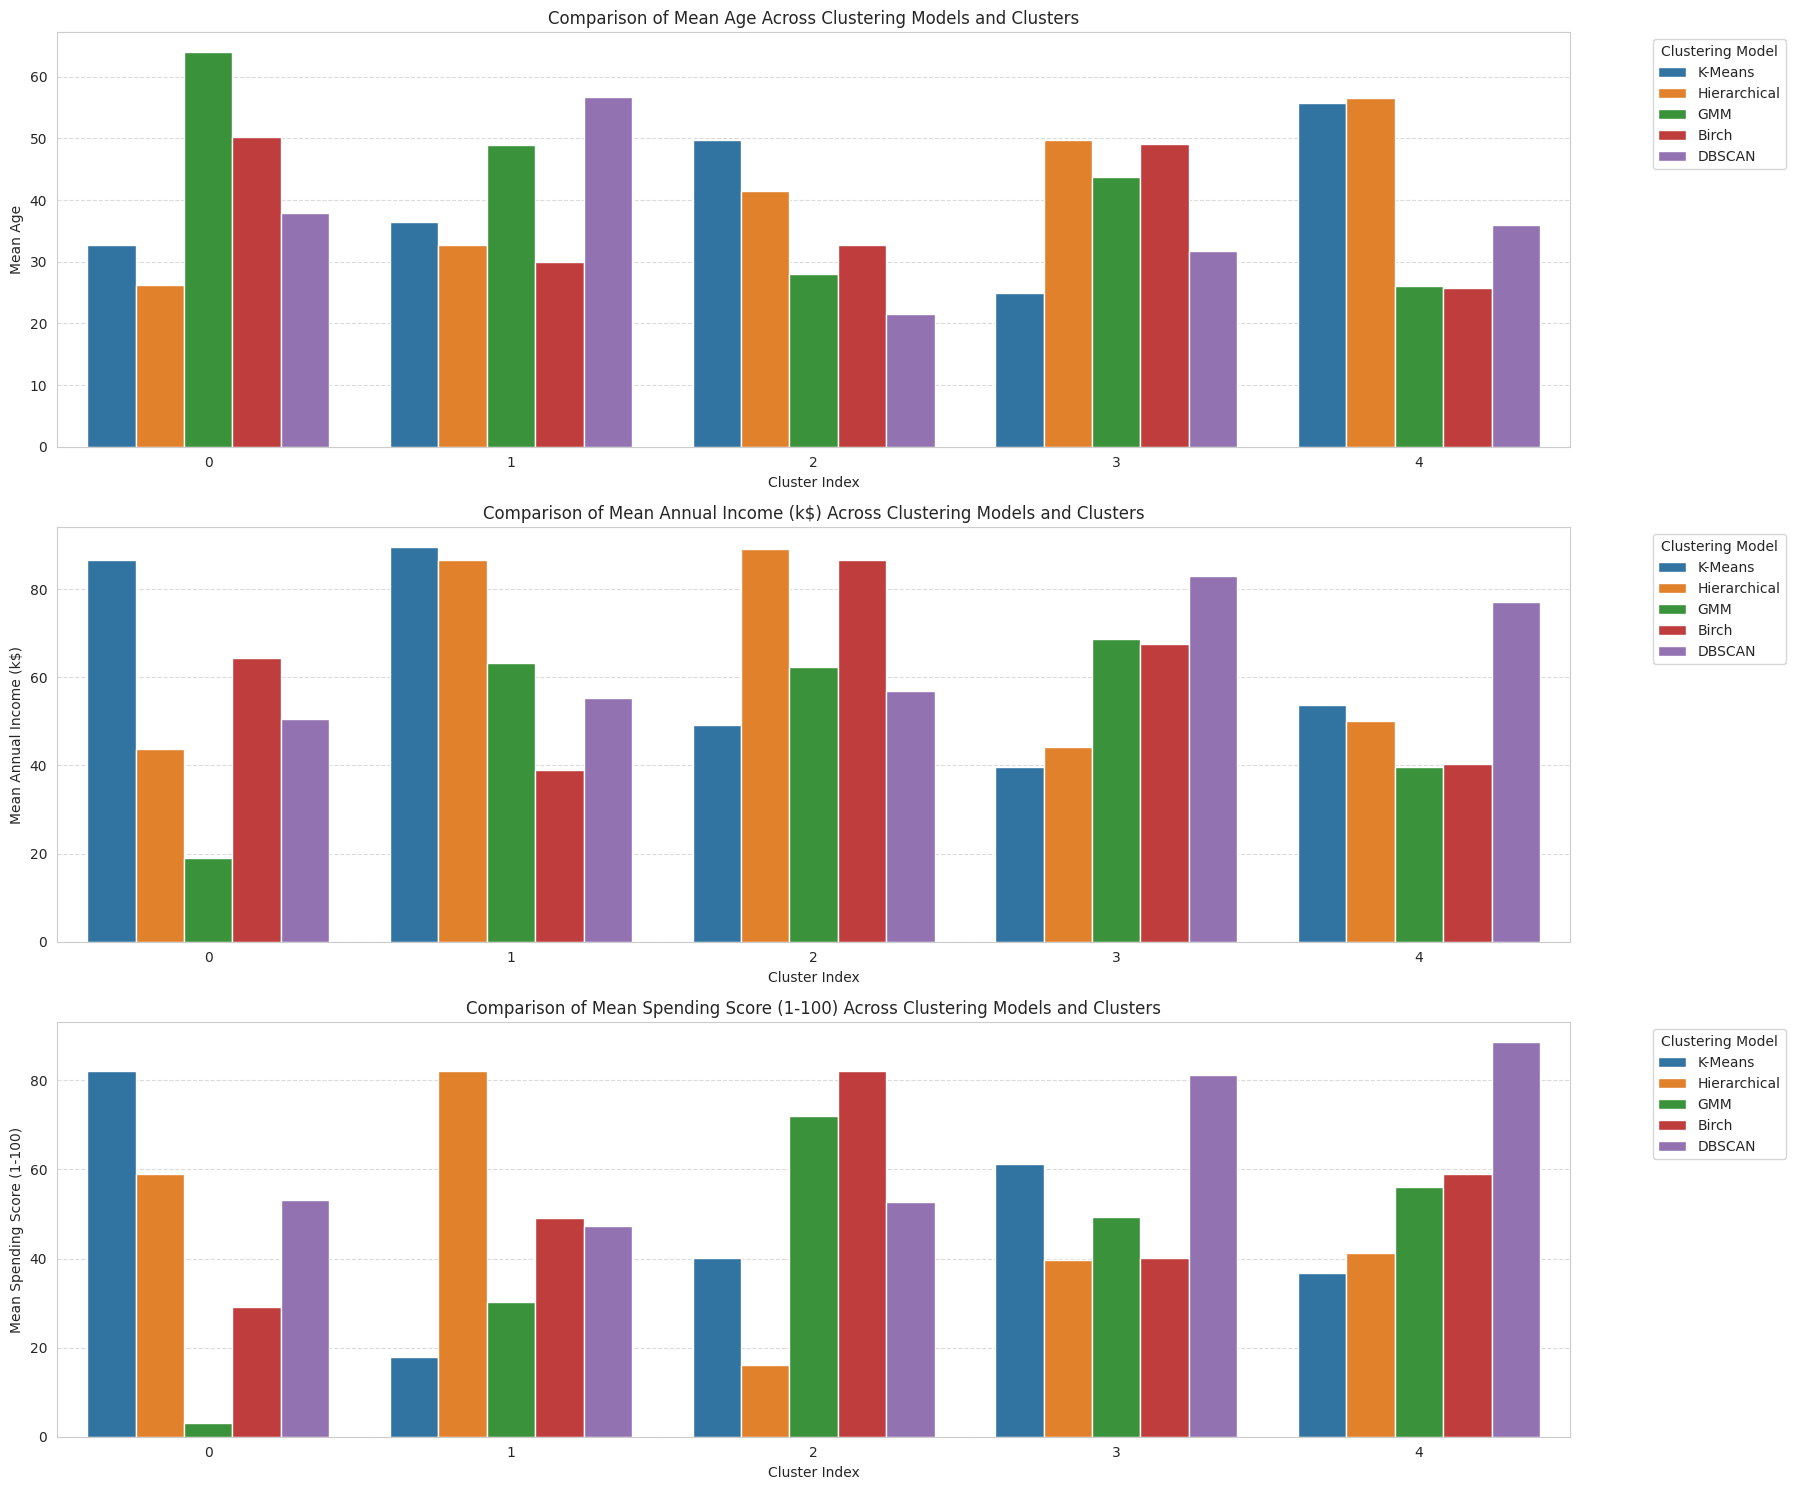

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for plotting by resetting index to make 'Cluster' a regular column
plot_data = all_cluster_means.reset_index()

# Define the features to visualize
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.figure(figsize=(18, 15))

for i, feature in enumerate(features):
    plt.subplot(3, 1, i + 1) # Create a 3x1 grid of plots
    sns.barplot(x='Cluster', y=feature, hue='Model', data=plot_data, palette='tab10')
    plt.title(f'Comparison of Mean {feature} Across Clustering Models and Clusters')
    plt.xlabel('Cluster Index')
    plt.ylabel(f'Mean {feature}')
    plt.legend(title='Clustering Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()